# Mixed distributions in QMCPy

Does the extra selector variable $V$ in hierarchical mixture sampling harm QMC enough to prefer componentwise integration? We compare both methods under equal work, starting with simple checks and then using 100 paired 10D Gaussian mixtures. The evidence depends strongly on the integrand, rather than pointing to one universal winner.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/mixed_distributions.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    !git clone -q --depth 1 --branch feature/mixed-distribution https://github.com/QMCSoftware/qmcpy.git /content/qmcpy
    !pip install -q -e /content/qmcpy

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from IPython.display import Markdown, display

from qmcpy import DigitalNetB2, Gaussian, Mixture

plt.style.use("seaborn-v0_8-whitegrid")


def show_table(headers, rows):
    """Render a compact table from the existing computed results."""
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


## 1. Two ways to handle the mixture

**Hierarchical mixture sampling.** First select a component according to the mixture probabilities, then apply that component's transform. In this QMC construction, selection is represented by the additional uniform coordinate $V$: the driver dimension is $d+1$ while the mixture output dimension is $d$. A point contains $d$ continuous coordinates $U$ and the selector $V$:
$$
Z=S(U), \qquad
X=\begin{cases}
T_1(Z), & V\le p,\\
T_2(Z), & V>p.
\end{cases}
$$
Crossing $V=p$ switches transformations and introduces a discontinuity in one coordinate.

**Componentwise integration.** Evaluate each component expectation separately and combine them using the mixture probabilities:
$$
I_j=\int f(T_j(S(U)))\,dU,
\qquad I=pI_1+(1-p)I_2.
$$

### Equal-work comparison

$N$ is the total number of evaluations of $f$. Hierarchical mixture sampling takes $N$ points, each producing one sample and one evaluation. Componentwise integration uses $N/2$ evaluations for each component, so $N/2+N/2=N$. For example, $N=1024$ means 1024 evaluations for hierarchical mixture sampling, or $512+512$ for componentwise integration.

The $N/2$ split is only a work allocation, not a claim of optimal allocation or equal mixture probabilities. The estimates retain weights $p$ and $1-p$: at $p=0.3$, $I=0.3I_1+0.7I_2$. This equal-work design is used throughout.


## 2. Why retain hierarchical mixture sampling?

QMCPy's `Mixture` directly generates samples from the actual mixture. Here the components are Gaussian with $(\mu_1,\sigma_1)=(-2,0.7)$ and $(\mu_2,\sigma_2)=(2.5,1.1)$, and $p=0.3$.


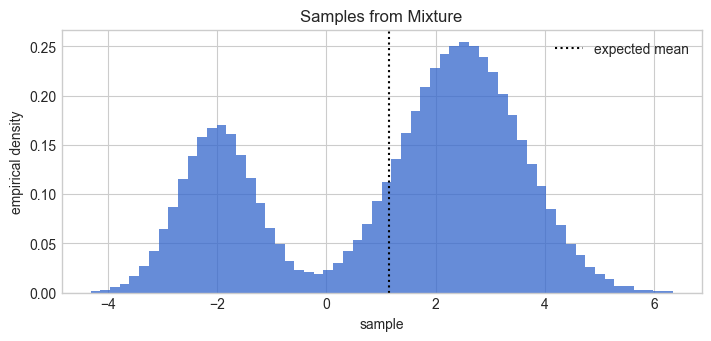

| Empirical sample mean | Expected mixture mean |
| --- | --- |
| 1.149730 | 1.150000 |

In [3]:
mu1, sigma1 = -2.0, 0.7
mu2, sigma2 = 2.5, 1.1
p = 0.3

components = [
    Gaussian(DigitalNetB2(1, seed=20260912), mean=mu1, covariance=sigma1**2),
    Gaussian(DigitalNetB2(1, seed=20260913), mean=mu2, covariance=sigma2**2),
]
mixture = Mixture(
    DigitalNetB2(2, seed=20260914),
    components,
    [p, 1 - p],
)
samples = mixture(4096)[:, 0]
expected_mean = p * mu1 + (1 - p) * mu2

fig, ax = plt.subplots(figsize=(7.0, 3.3), layout="constrained")
ax.hist(samples, bins=60, density=True, color="#3366CC", alpha=0.75)
ax.axvline(expected_mean, color="black", linestyle=":", label="expected mean")
ax.set(xlabel="sample", ylabel="empirical density", title="Samples from Mixture")
ax.legend(frameon=False)
plt.show()

show_table(
    ["Empirical sample mean", "Expected mixture mean"],
    [[f"{samples.mean():.6f}", f"{expected_mean:.6f}"]],
)


### What this tells us

The two clusters come from the two Gaussian components, and the empirical mean is close to the expected mixture mean. Hierarchical mixture sampling directly produces a single sample set from the mixture. Componentwise integration is an expectation calculation and is not itself a direct mixture-sampling construction.


## 3. Initial 1D check

For these Gaussians, $S(U)=\Phi^{-1}(U)$, $T_1(Z)=-2+0.7Z$, and $T_2(Z)=2.5+1.1Z$. Even with a smooth $f$, fixing $U$ and moving $V$ across $0.3$ switches the value of $f(T_j(Z))$.

We try **$f(x)=x^2$** and **$f(x)=\cos(x)$**, using the exact Gaussian identities
$$
E[X^2]=\mu^2+\sigma^2,\qquad
E[\cos(X)]=e^{-\sigma^2/2}\cos(\mu).
$$
The mixture references are their probability-weighted combinations; for $x^2$ this is $6.569$. All convergence comparisons use randomized DigitalNetB2 points, 32 randomizations, budgets $N=2^6,\ldots,2^{15}$, and empirical log-log slope fits over the largest five budgets.


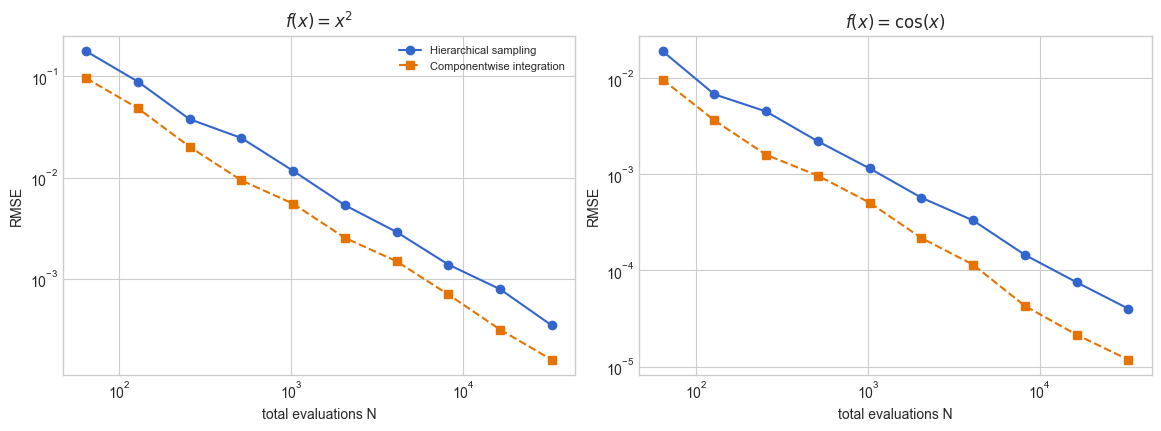

| Function | Hierarchical sampling slope | Componentwise integration slope | Final Hierarchical sampling RMSE (N=32768) | Final Componentwise integration RMSE |
| --- | --- | --- | --- | --- |
| $x^2$ | -0.98 | -1.03 | 0.000343876 | 0.000157216 |
| $\cos(x)$ | -0.98 | -1.08 | 4.00019e-05 | 1.17855e-05 |

In [4]:
sample_sizes = 2 ** np.arange(6, 16)
replications = 32
n_max = int(sample_sizes[-1])
exact = p * (mu1**2 + sigma1**2) + (1 - p) * (mu2**2 + sigma2**2)
exact_cos = (
    p * np.exp(-sigma1**2 / 2) * np.cos(mu1)
    + (1 - p) * np.exp(-sigma2**2 / 2) * np.cos(mu2)
)


def to_normal(u):
    lower = np.nextafter(0.0, 1.0)
    upper = np.nextafter(1.0, 0.0)
    return norm.ppf(np.clip(u, lower, upper))


# Hierarchical mixture sampling in the calculation. Columns are U and V, in that order.
points = DigitalNetB2(
    2, seed=20260922, replications=replications, randomize="LMS DS"
)(n_max)
z = to_normal(points[..., 0])
v = points[..., 1]
x = np.where(v <= p, mu1 + sigma1 * z, mu2 + sigma2 * z)
values_using_v = x**2
values_using_v_cos = np.cos(x)

# Componentwise integration, with N/2 points for each.
u1 = DigitalNetB2(
    1, seed=20260923, replications=replications, randomize="LMS DS"
)(n_max // 2)[..., 0]
u2 = DigitalNetB2(
    1, seed=20260924, replications=replications, randomize="LMS DS"
)(n_max // 2)[..., 0]
x1 = mu1 + sigma1 * to_normal(u1)
x2 = mu2 + sigma2 * to_normal(u2)
values_1 = x1**2
values_2 = x2**2
values_1_cos = np.cos(x1)
values_2_cos = np.cos(x2)

rmse_using_v = []
rmse_separate = []
rmse_using_v_cos = []
rmse_separate_cos = []
for n in sample_sizes:
    estimates_using_v = values_using_v[:, :n].mean(axis=1)
    estimates_separate = (
        p * values_1[:, : n // 2].mean(axis=1)
        + (1 - p) * values_2[:, : n // 2].mean(axis=1)
    )
    rmse_using_v.append(np.sqrt(np.mean((estimates_using_v - exact) ** 2)))
    rmse_separate.append(np.sqrt(np.mean((estimates_separate - exact) ** 2)))
    estimates_using_v_cos = values_using_v_cos[:, :n].mean(axis=1)
    estimates_separate_cos = (
        p * values_1_cos[:, : n // 2].mean(axis=1)
        + (1 - p) * values_2_cos[:, : n // 2].mean(axis=1)
    )
    rmse_using_v_cos.append(
        np.sqrt(np.mean((estimates_using_v_cos - exact_cos) ** 2))
    )
    rmse_separate_cos.append(
        np.sqrt(np.mean((estimates_separate_cos - exact_cos) ** 2))
    )

rmse_using_v = np.asarray(rmse_using_v)
rmse_separate = np.asarray(rmse_separate)
rmse_using_v_cos = np.asarray(rmse_using_v_cos)
rmse_separate_cos = np.asarray(rmse_separate_cos)
fit = slice(-5, None)
slope_using_v = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_using_v[fit]), 1
)[0]
slope_separate = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate[fit]), 1
)[0]
slope_using_v_cos = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_using_v_cos[fit]), 1
)[0]
slope_separate_cos = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate_cos[fit]), 1
)[0]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained")
for ax, errors_v, errors_separate, title in [
    (axes[0], rmse_using_v, rmse_separate, r"$f(x)=x^2$"),
    (axes[1], rmse_using_v_cos, rmse_separate_cos, r"$f(x)=\cos(x)$"),
]:
    ax.loglog(
        sample_sizes, errors_v, "o-", color="#3366CC",
        label="Hierarchical sampling",
    )
    ax.loglog(
        sample_sizes, errors_separate, "s--", color="#E67300",
        label="Componentwise integration",
    )
    ax.set(xlabel="total evaluations N", ylabel="RMSE", title=title)
axes[0].legend(frameon=False, fontsize=8)
plt.show()

show_table(
    ["Function", "Hierarchical sampling slope", "Componentwise integration slope",
     f"Final Hierarchical sampling RMSE (N={n_max})", "Final Componentwise integration RMSE"],
    [
        [r"$x^2$", f"{slope_using_v:.2f}", f"{slope_separate:.2f}",
         f"{rmse_using_v[-1]:.6g}", f"{rmse_separate[-1]:.6g}"],
        [r"$\cos(x)$", f"{slope_using_v_cos:.2f}", f"{slope_separate_cos:.2f}",
         f"{rmse_using_v_cos[-1]:.6g}", f"{rmse_separate_cos[-1]:.6g}"],
    ],
)


### What this tells us

Both smooth functions give similar fitted slopes near $-1$ for the two methods, while Componentwise integration has smaller final RMSE. In these simple examples, Hierarchical mixture sampling still gives fitted slopes close to those from Componentwise integration; harder cases are needed before drawing a broader conclusion.

## 4. Higher-dimensional validation

### From 5D to 10D

We retain three stepping stones: a 5D mixture at $p=0.3$, and a fixed pair of 10D components at $p=0.3$ and $p=0.1$. Their covariance matrices are dense and non-diagonal. The 10D component parameters are unchanged between probabilities, although those two fixed-case runs use different QMC randomizations.

For $X=\mu+AZ$, $Z\sim N(0,I)$,
$$
\Sigma=AA^\mathsf{T},\qquad
E[X^\mathsf{T}X]=\mu^\mathsf{T}\mu+\operatorname{trace}(\Sigma).
$$
The exact mixture value is the probability-weighted combination of these moments. In the code, row samples use `Z @ A.T + mu`. Each analytical value is checked with one million ordinary random samples; these checks are not extra methods in the QMC comparison.


In [5]:
d = 5
p5 = 0.3
rng5 = np.random.default_rng(123)
mu1_5d = rng5.standard_normal(d)
mu2_5d = rng5.standard_normal(d)
A1 = rng5.standard_normal((d, d)) / np.sqrt(d)
A2 = rng5.standard_normal((d, d)) / np.sqrt(d)
Sigma1 = A1 @ A1.T
Sigma2 = A2 @ A2.T
exact5 = (
    p5 * (mu1_5d @ mu1_5d + np.trace(Sigma1))
    + (1 - p5) * (mu2_5d @ mu2_5d + np.trace(Sigma2))
)

# Sanity check only: this ordinary random sample is not a curve in the QMC plot.
mc_rng5 = np.random.default_rng(456)
mc_n5 = 1_000_000
z_mc5 = mc_rng5.standard_normal((mc_n5, d))
choose1_mc5 = mc_rng5.random(mc_n5) < p5
x_mc5 = np.empty_like(z_mc5)
x_mc5[choose1_mc5] = z_mc5[choose1_mc5] @ A1.T + mu1_5d
x_mc5[~choose1_mc5] = z_mc5[~choose1_mc5] @ A2.T + mu2_5d
values_mc5 = np.sum(x_mc5**2, axis=-1)
mc_mean5 = values_mc5.mean()
mc_se5 = values_mc5.std(ddof=1) / np.sqrt(mc_n5)


In [6]:
# Hierarchical mixture sampling: d normal inputs followed by one decision coordinate.
points5 = DigitalNetB2(
    d + 1, seed=124, replications=replications, randomize="LMS DS"
)(n_max)
# to_normal clips away from 0 and 1 with np.nextafter before norm.ppf.
z5 = to_normal(points5[..., :d])
choose1_5 = points5[..., -1] < p5
x5 = np.empty_like(z5)
x5[choose1_5] = z5[choose1_5] @ A1.T + mu1_5d
x5[~choose1_5] = z5[~choose1_5] @ A2.T + mu2_5d
values_v5 = np.sum(x5**2, axis=-1)

# Componentwise integration: N/2 evaluations for each, with the same mixture weights.
u1_5 = DigitalNetB2(
    d, seed=125, replications=replications, randomize="LMS DS"
)(n_max // 2)
u2_5 = DigitalNetB2(
    d, seed=126, replications=replications, randomize="LMS DS"
)(n_max // 2)
x1_5 = to_normal(u1_5) @ A1.T + mu1_5d
x2_5 = to_normal(u2_5) @ A2.T + mu2_5d
values1_5 = np.sum(x1_5**2, axis=-1)
values2_5 = np.sum(x2_5**2, axis=-1)

rmse_v5 = []
rmse_separate5 = []
for n in sample_sizes:
    estimates_v5 = values_v5[:, :n].mean(axis=1)
    estimates_separate5 = (
        p5 * values1_5[:, : n // 2].mean(axis=1)
        + (1 - p5) * values2_5[:, : n // 2].mean(axis=1)
    )
    rmse_v5.append(np.sqrt(np.mean((estimates_v5 - exact5) ** 2)))
    rmse_separate5.append(np.sqrt(np.mean((estimates_separate5 - exact5) ** 2)))

rmse_v5 = np.asarray(rmse_v5)
rmse_separate5 = np.asarray(rmse_separate5)
# As above, fit the five largest budgets.
slope_v5 = np.polyfit(np.log(sample_sizes[fit]), np.log(rmse_v5[fit]), 1)[0]
slope_separate5 = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate5[fit]), 1
)[0]


In [7]:
d10 = 10
p10 = 0.3
rng10 = np.random.default_rng(321)
mu1_10d = rng10.standard_normal(d10)
mu2_10d = rng10.standard_normal(d10)
A1_10 = rng10.standard_normal((d10, d10)) / np.sqrt(d10)
A2_10 = rng10.standard_normal((d10, d10)) / np.sqrt(d10)
Sigma1_10 = A1_10 @ A1_10.T
Sigma2_10 = A2_10 @ A2_10.T
exact10 = (
    p10 * (mu1_10d @ mu1_10d + np.trace(Sigma1_10))
    + (1 - p10) * (mu2_10d @ mu2_10d + np.trace(Sigma2_10))
)

# Sanity check only, not a third method in the QMC comparison.
mc_rng10 = np.random.default_rng(654)
mc_n10 = 1_000_000
z_mc10 = mc_rng10.standard_normal((mc_n10, d10))
choose1_mc10 = mc_rng10.random(mc_n10) < p10
x_mc10 = np.empty_like(z_mc10)
x_mc10[choose1_mc10] = z_mc10[choose1_mc10] @ A1_10.T + mu1_10d
x_mc10[~choose1_mc10] = z_mc10[~choose1_mc10] @ A2_10.T + mu2_10d
values_mc10 = np.sum(x_mc10**2, axis=-1)
mc_mean10 = values_mc10.mean()
mc_se10 = values_mc10.std(ddof=1) / np.sqrt(mc_n10)

off_diagonal10 = ~np.eye(d10, dtype=bool)


In [8]:
# Hierarchical mixture sampling: ten normal inputs followed by one decision coordinate.
points10 = DigitalNetB2(
    d10 + 1, seed=322, replications=replications, randomize="LMS DS"
)(n_max)
# Reuse the safe clipping before norm.ppf; row samples use Z @ A.T + mu.
z10 = to_normal(points10[..., :d10])
choose1_10 = points10[..., -1] < p10
x10 = np.empty_like(z10)
x10[choose1_10] = z10[choose1_10] @ A1_10.T + mu1_10d
x10[~choose1_10] = z10[~choose1_10] @ A2_10.T + mu2_10d
values_v10 = np.sum(x10**2, axis=-1)

# Componentwise integration: N/2 evaluations for each, with weights 0.3 and 0.7.
u1_10 = DigitalNetB2(
    d10, seed=323, replications=replications, randomize="LMS DS"
)(n_max // 2)
u2_10 = DigitalNetB2(
    d10, seed=324, replications=replications, randomize="LMS DS"
)(n_max // 2)
x1_10 = to_normal(u1_10) @ A1_10.T + mu1_10d
x2_10 = to_normal(u2_10) @ A2_10.T + mu2_10d
values1_10 = np.sum(x1_10**2, axis=-1)
values2_10 = np.sum(x2_10**2, axis=-1)

rmse_v10 = []
rmse_separate10 = []
for n in sample_sizes:
    estimates_v10 = values_v10[:, :n].mean(axis=1)
    estimates_separate10 = (
        p10 * values1_10[:, : n // 2].mean(axis=1)
        + (1 - p10) * values2_10[:, : n // 2].mean(axis=1)
    )
    rmse_v10.append(np.sqrt(np.mean((estimates_v10 - exact10) ** 2)))
    rmse_separate10.append(np.sqrt(np.mean((estimates_separate10 - exact10) ** 2)))

rmse_v10 = np.asarray(rmse_v10)
rmse_separate10 = np.asarray(rmse_separate10)
# Reuse the fit over the five largest budgets.
slope_v10 = np.polyfit(np.log(sample_sizes[fit]), np.log(rmse_v10[fit]), 1)[0]
slope_separate10 = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate10[fit]), 1
)[0]


In [9]:
p10_imbalanced = 0.1
exact10_imbalanced = (
    p10_imbalanced * (mu1_10d @ mu1_10d + np.trace(Sigma1_10))
    + (1 - p10_imbalanced) * (mu2_10d @ mu2_10d + np.trace(Sigma2_10))
)

# Sanity check only: reuse the component parameters, not the QMC points.
mc_rng10_imbalanced = np.random.default_rng(754)
mc_n10_imbalanced = 1_000_000
z_mc10_imbalanced = mc_rng10_imbalanced.standard_normal((mc_n10_imbalanced, d10))
choose1_mc10_imbalanced = (
    mc_rng10_imbalanced.random(mc_n10_imbalanced) < p10_imbalanced
)
x_mc10_imbalanced = np.empty_like(z_mc10_imbalanced)
x_mc10_imbalanced[choose1_mc10_imbalanced] = (
    z_mc10_imbalanced[choose1_mc10_imbalanced] @ A1_10.T + mu1_10d
)
x_mc10_imbalanced[~choose1_mc10_imbalanced] = (
    z_mc10_imbalanced[~choose1_mc10_imbalanced] @ A2_10.T + mu2_10d
)
values_mc10_imbalanced = np.sum(x_mc10_imbalanced**2, axis=-1)
mc_mean10_imbalanced = values_mc10_imbalanced.mean()
mc_se10_imbalanced = (
    values_mc10_imbalanced.std(ddof=1) / np.sqrt(mc_n10_imbalanced)
)


| d | p | Covariances | Analytical value | MC check | MC standard error |
| --- | --- | --- | --- | --- | --- |
| 5 | 0.3 | Dense/non-diagonal | 6.565568616 | 6.574820424 | 0.005233175 |
| 10 | 0.3 | Dense/non-diagonal | 12.595533665 | 12.595350591 | 0.008379353 |
| 10 | 0.1 | Dense/non-diagonal | 10.450854779 | 10.454013577 | 0.006753699 |

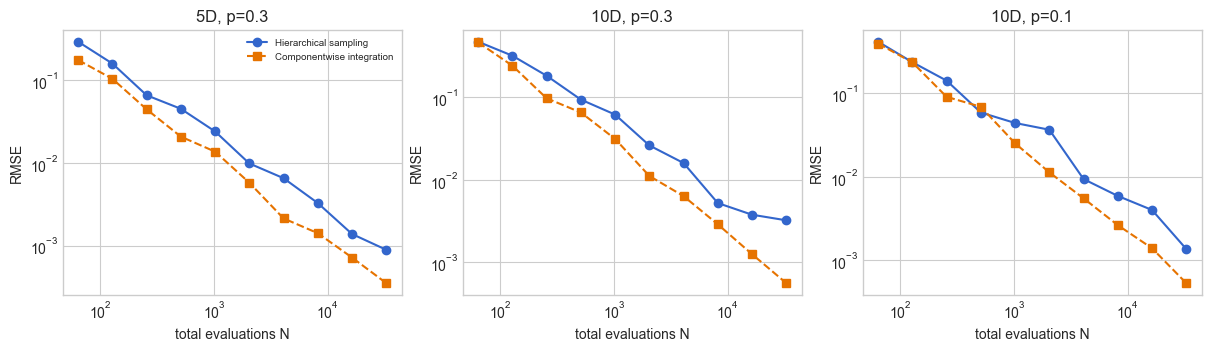

| Case | Hierarchical sampling slope | Componentwise integration slope | Final RMSE (N=32768) |
| --- | --- | --- | --- |
| 5D, p=0.3 | -0.918 | -0.964 | Hierarchical sampling: 0.000890547877; Componentwise integration: 0.000351914554 |
| 10D, p=0.3 | -0.813 | -1.099 | Hierarchical sampling: 0.00321166253; Componentwise integration: 0.00055389888 |
| 10D, p=0.1 | -1.069 | -1.077 | Hierarchical sampling: 0.00137168872; Componentwise integration: 0.000536600729 |

In [10]:
# Hierarchical mixture sampling: reuse the 10D transforms with a new selector threshold and QMC seed.
points10_imbalanced = DigitalNetB2(
    d10 + 1, seed=422, replications=replications, randomize="LMS DS"
)(n_max)
z10_imbalanced = to_normal(points10_imbalanced[..., :d10])
choose1_10_imbalanced = points10_imbalanced[..., -1] < p10_imbalanced
x10_imbalanced = np.empty_like(z10_imbalanced)
x10_imbalanced[choose1_10_imbalanced] = (
    z10_imbalanced[choose1_10_imbalanced] @ A1_10.T + mu1_10d
)
x10_imbalanced[~choose1_10_imbalanced] = (
    z10_imbalanced[~choose1_10_imbalanced] @ A2_10.T + mu2_10d
)
values_v10_imbalanced = np.sum(x10_imbalanced**2, axis=-1)

# Componentwise integration: equal work, but mixture weights remain 0.1 and 0.9.
u1_10_imbalanced = DigitalNetB2(
    d10, seed=423, replications=replications, randomize="LMS DS"
)(n_max // 2)
u2_10_imbalanced = DigitalNetB2(
    d10, seed=424, replications=replications, randomize="LMS DS"
)(n_max // 2)
x1_10_imbalanced = to_normal(u1_10_imbalanced) @ A1_10.T + mu1_10d
x2_10_imbalanced = to_normal(u2_10_imbalanced) @ A2_10.T + mu2_10d
values1_10_imbalanced = np.sum(x1_10_imbalanced**2, axis=-1)
values2_10_imbalanced = np.sum(x2_10_imbalanced**2, axis=-1)

rmse_v10_imbalanced = []
rmse_separate10_imbalanced = []
for n in sample_sizes:
    estimates_v10_imbalanced = values_v10_imbalanced[:, :n].mean(axis=1)
    estimates_separate10_imbalanced = (
        p10_imbalanced * values1_10_imbalanced[:, : n // 2].mean(axis=1)
        + (1 - p10_imbalanced) * values2_10_imbalanced[:, : n // 2].mean(axis=1)
    )
    rmse_v10_imbalanced.append(
        np.sqrt(np.mean((estimates_v10_imbalanced - exact10_imbalanced) ** 2))
    )
    rmse_separate10_imbalanced.append(
        np.sqrt(np.mean((estimates_separate10_imbalanced - exact10_imbalanced) ** 2))
    )

rmse_v10_imbalanced = np.asarray(rmse_v10_imbalanced)
rmse_separate10_imbalanced = np.asarray(rmse_separate10_imbalanced)
slope_v10_imbalanced = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_v10_imbalanced[fit]), 1
)[0]
slope_separate10_imbalanced = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate10_imbalanced[fit]), 1
)[0]


# Present the three existing validation cases together.
validation_rows = []
for dimension, probability, covariances, reference, mc_mean, mc_se in [
    (d, p5, (Sigma1, Sigma2), exact5, mc_mean5, mc_se5),
    (d10, p10, (Sigma1_10, Sigma2_10), exact10, mc_mean10, mc_se10),
    (d10, p10_imbalanced, (Sigma1_10, Sigma2_10),
     exact10_imbalanced, mc_mean10_imbalanced, mc_se10_imbalanced),
]:
    off_diagonal = ~np.eye(dimension, dtype=bool)
    dense = all(np.all(cov[off_diagonal] != 0) for cov in covariances)
    validation_rows.append([
        dimension, probability, "Dense/non-diagonal" if dense else "Check covariance",
        f"{reference:.9f}", f"{mc_mean:.9f}", f"{mc_se:.9f}",
    ])
show_table(
    ["d", "p", "Covariances", "Analytical value", "MC check", "MC standard error"],
    validation_rows,
)

fixed_cases = [
    ("5D, p=0.3", rmse_v5, rmse_separate5, slope_v5, slope_separate5),
    ("10D, p=0.3", rmse_v10, rmse_separate10, slope_v10, slope_separate10),
    ("10D, p=0.1", rmse_v10_imbalanced, rmse_separate10_imbalanced,
     slope_v10_imbalanced, slope_separate10_imbalanced),
]
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.4), layout="constrained")
for ax, (case, errors_v, errors_separate, _, _) in zip(axes, fixed_cases):
    ax.loglog(
        sample_sizes, errors_v, "o-", color="#3366CC",
        label="Hierarchical sampling",
    )
    ax.loglog(
        sample_sizes, errors_separate, "s--", color="#E67300",
        label="Componentwise integration",
    )
    ax.set(xlabel="total evaluations N", ylabel="RMSE", title=case)
axes[0].legend(frameon=False, fontsize=7)
plt.show()

show_table(
    ["Case", "Hierarchical sampling slope", "Componentwise integration slope", f"Final RMSE (N={n_max})"],
    [
        [case, f"{sv:.3f}", f"{ss:.3f}",
         f"Hierarchical sampling: {ev[-1]:.9g}; Componentwise integration: {es[-1]:.9g}"]
        for case, ev, es, sv, ss in fixed_cases
    ],
)


### What this tells us

The individual higher-dimensional cases vary enough that a single case is not reliable evidence. This motivates the paired 100-mixture study below.


## 5. Main evidence: 100 paired 10D mixtures

We generate 100 pairs of correlated 10D Gaussian components: standard-normal mean vectors and dense factors $A_j$ scaled by $1/\sqrt{10}$, with $\Sigma_j=A_jA_j^\mathsf{T}$. Each pair is tested at $p=0.3$ and $p=0.1$, keeping the same component parameters and randomized QMC point sets between probabilities.

The integrand remains $f(x)=x^\mathsf{T}x$, with 32 randomizations and the budgets and fitting rule from Section 3. Fixed seeds make the cases reproducible; processing one case at a time limits memory use. The nonlinear study below will reuse these same cases and points.

Each curve is the median RMSE across mixtures. Shaded bands are the 25th–75th percentiles **across the 100 mixtures**, not confidence intervals.


In [11]:
from time import perf_counter


def random_mixture_rmse(case_seed, budgets, n_rep, probabilities):
    """Return RMSE curves indexed by probability, method (Hierarchical sampling/Componentwise integration), budget."""
    d_case = 10
    parameter_seed, v_seed, c1_seed, c2_seed = case_seed.spawn(4)
    rng_case = np.random.default_rng(parameter_seed)
    mean1 = rng_case.standard_normal(d_case)
    mean2 = rng_case.standard_normal(d_case)
    factor1 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    factor2 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    covariance1 = factor1 @ factor1.T
    covariance2 = factor2 @ factor2.T
    moment1 = mean1 @ mean1 + np.trace(covariance1)
    moment2 = mean2 @ mean2 + np.trace(covariance2)
    max_budget = int(budgets[-1])

    # These component estimates are reused unchanged for both probabilities.
    component_estimates = []
    for mean, factor, seed in [
        (mean1, factor1, c1_seed), (mean2, factor2, c2_seed)
    ]:
        u_case = DigitalNetB2(
            d_case, seed=seed, replications=n_rep, randomize="LMS DS"
        )(max_budget // 2)
        values = np.sum((to_normal(u_case) @ factor.T + mean) ** 2, axis=-1)
        component_estimates.append(
            np.stack([values[:, : n // 2].mean(axis=1) for n in budgets], axis=1)
        )
        del u_case, values

    # Generate once per case: both probabilities use exactly these U and V.
    points_case = DigitalNetB2(
        d_case + 1, seed=v_seed, replications=n_rep, randomize="LMS DS"
    )(max_budget)
    normals = to_normal(points_case[..., :d_case])
    selector = points_case[..., -1].copy()
    del points_case

    curves = np.empty((len(probabilities), 2, len(budgets)))
    for probability_index, probability in enumerate(probabilities):
        exact_case = probability * moment1 + (1 - probability) * moment2
        choose1 = selector < probability
        values = np.empty(selector.shape)
        values[choose1] = np.sum(
            (normals[choose1] @ factor1.T + mean1) ** 2, axis=-1
        )
        values[~choose1] = np.sum(
            (normals[~choose1] @ factor2.T + mean2) ** 2, axis=-1
        )
        estimates_v = np.stack(
            [values[:, :n].mean(axis=1) for n in budgets], axis=1
        )
        estimates_separate = (
            probability * component_estimates[0]
            + (1 - probability) * component_estimates[1]
        )
        curves[probability_index, 0] = np.sqrt(
            np.mean((estimates_v - exact_case) ** 2, axis=0)
        )
        curves[probability_index, 1] = np.sqrt(
            np.mean((estimates_separate - exact_case) ** 2, axis=0)
        )
    return curves


In [12]:
n_cases100 = 100
d100 = 10
p_values100 = [0.3, 0.1]
master_seed100 = 20260925
case_seeds100 = np.random.SeedSequence(master_seed100).spawn(n_cases100)

# Axes: random case, probability, method (Hierarchical sampling/Componentwise integration), sample budget.
rmse_cases100 = np.empty((n_cases100, len(p_values100), 2, len(sample_sizes)))
slopes_cases100 = np.empty((n_cases100, len(p_values100), 2))
started100 = perf_counter()
for case_index100, case_seed100 in enumerate(case_seeds100):
    curves100 = random_mixture_rmse(
        case_seed100, sample_sizes, replications, p_values100
    )
    rmse_cases100[case_index100] = curves100
    for probability_index100 in range(len(p_values100)):
        for method_index100 in range(2):
            slopes_cases100[case_index100, probability_index100, method_index100] = (
                np.polyfit(
                    np.log(sample_sizes[fit]),
                    np.log(curves100[probability_index100, method_index100, fit]),
                    1,
                )[0]
            )
elapsed100 = perf_counter() - started100
final_ratios100 = rmse_cases100[:, :, 0, -1] / rmse_cases100[:, :, 1, -1]


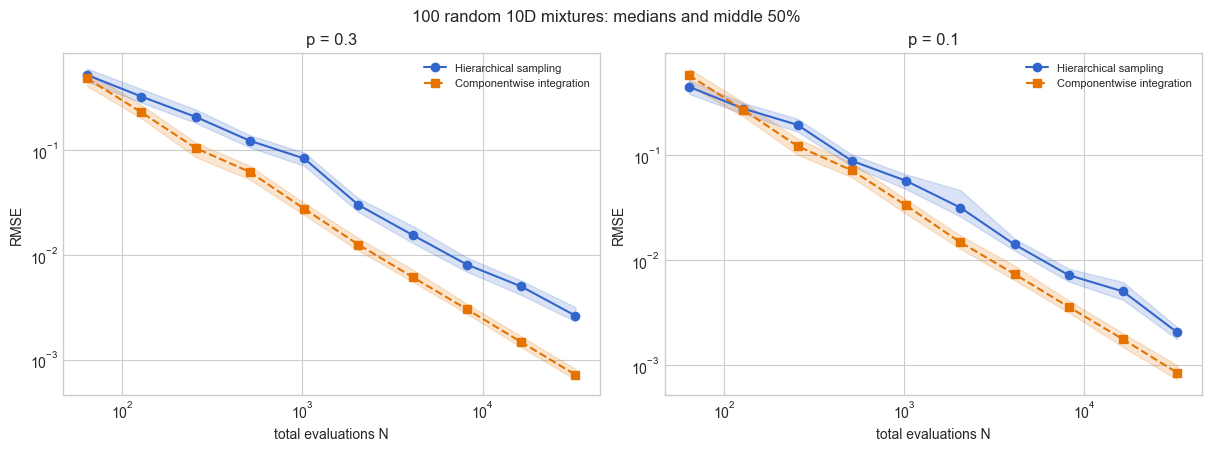

| p | Method | Median slope | 25%–75% slope | Median final RMSE |
| --- | --- | --- | --- | --- |
| 0.3 | Hierarchical sampling | -0.875 | [-0.928, -0.797] | 0.00262255 |
| 0.3 | Componentwise integration | -1.018 | [-1.090, -0.982] | 0.000715223 |
| 0.1 | Hierarchical sampling | -0.956 | [-1.023, -0.887] | 0.00202802 |
| 0.1 | Componentwise integration | -1.031 | [-1.088, -0.991] | 0.000837559 |

In [13]:
rmse_quantiles100 = np.quantile(rmse_cases100, [0.25, 0.5, 0.75], axis=0)
slope_quantiles100 = np.quantile(slopes_cases100, [0.25, 0.5, 0.75], axis=0)
ratio_medians100 = np.median(final_ratios100, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), layout="constrained")
for probability_index100, (ax, probability100) in enumerate(zip(axes, p_values100)):
    for method_index100, color100, style100, label100 in [
        (0, "#3366CC", "o-", "Hierarchical sampling"),
        (1, "#E67300", "s--", "Componentwise integration"),
    ]:
        lower100, median100, upper100 = rmse_quantiles100[
            :, probability_index100, method_index100
        ]
        ax.loglog(sample_sizes, median100, style100, color=color100, label=label100)
        ax.fill_between(sample_sizes, lower100, upper100, color=color100, alpha=0.18)
    ax.set(xlabel="total evaluations N", ylabel="RMSE", title=f"p = {probability100}")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("100 random 10D mixtures: medians and middle 50%")
plt.show()

quadratic_rows = []
for probability_index100, probability100 in enumerate(p_values100):
    for method_index100, method100 in enumerate(["Hierarchical sampling", "Componentwise integration"]):
        q25, median_slope, q75 = slope_quantiles100[
            :, probability_index100, method_index100
        ]
        median_final = rmse_quantiles100[1, probability_index100, method_index100, -1]
        quadratic_rows.append([
            probability100, method100, f"{median_slope:.3f}",
            f"[{q25:.3f}, {q75:.3f}]", f"{median_final:.6g}",
        ])
show_table(
    ["p", "Method", "Median slope", "25%–75% slope", "Median final RMSE"],
    quadratic_rows,
)


### What this tells us

For $x^\mathsf{T}x$, Componentwise integration has more negative median fitted slopes and substantially smaller final RMSE. The median per-case final RMSE ratios, Hierarchical mixture sampling / Componentwise integration, are **3.779** at $p=0.3$ and **2.343** at $p=0.1$. Under this equal-work design, the evidence favors Componentwise integration for estimating this expectation, not for every integrand.

The quadratic result motivates a paired change of integrand: does that advantage persist for a smooth but oscillatory function?


## 6. Does that conclusion depend on $f$?

Unlike the quadratic, $f(x)=\cos(x^\mathsf{T}x)$ is smooth and bounded but oscillatory. Before repeating the 100-case study, we validate its reference using the existing fixed 10D mixture at $p=0.3$.

### Analytical reference and fixed-case check

For a Gaussian component,
$$
E[e^{iX^\mathsf{T}X}]
=\det(I-2i\Sigma)^{-1/2}
\exp\!\left(i\mu^\mathsf{T}(I-2i\Sigma)^{-1}\mu\right).
$$
Its real part gives the cosine expectation; the mixture reference is the weighted sum. The helper uses covariance eigenvalues and individual complex logarithms to follow the square-root branch continuously from frequency zero, avoiding an explicit inverse or an ambiguous square root of the combined determinant. The independent million-sample Monte Carlo check stops execution if the discrepancy exceeds five estimated standard errors.


In [14]:
def gaussian_cos_squared_norm(mean, covariance):
    """Evaluate E[cos(X.T @ X)] using covariance eigenvalues."""
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    rotated_mean = eigenvectors.T @ mean
    factors = 1 - 2j * eigenvalues
    log_characteristic = (
        -0.5 * np.sum(np.log1p(-2j * eigenvalues))
        + 1j * np.sum(rotated_mean**2 / factors)
    )
    return np.exp(log_characteristic).real


p_cos10 = 0.3
exact_cos_component1 = gaussian_cos_squared_norm(mu1_10d, Sigma1_10)
exact_cos_component2 = gaussian_cos_squared_norm(mu2_10d, Sigma2_10)
exact_cos_mixture = (
    p_cos10 * exact_cos_component1 + (1 - p_cos10) * exact_cos_component2
)

# Independent ordinary Monte Carlo check; no new component parameters.
mc_rng_cos10 = np.random.default_rng(854)
mc_n_cos10 = 1_000_000
z_mc_cos10 = mc_rng_cos10.standard_normal((mc_n_cos10, d10))
choose1_mc_cos10 = mc_rng_cos10.random(mc_n_cos10) < p_cos10
x_mc_cos10 = np.empty_like(z_mc_cos10)
x_mc_cos10[choose1_mc_cos10] = (
    z_mc_cos10[choose1_mc_cos10] @ A1_10.T + mu1_10d
)
x_mc_cos10[~choose1_mc_cos10] = (
    z_mc_cos10[~choose1_mc_cos10] @ A2_10.T + mu2_10d
)
values_mc_cos10 = np.cos(np.sum(x_mc_cos10**2, axis=-1))
mc_mean_cos10 = values_mc_cos10.mean()
mc_se_cos10 = values_mc_cos10.std(ddof=1) / np.sqrt(mc_n_cos10)
mc_difference_cos10 = abs(mc_mean_cos10 - exact_cos_mixture)

if mc_difference_cos10 > 5 * mc_se_cos10:
    raise RuntimeError(
        "Analytical reference and Monte Carlo check disagree by more than "
        "five standard errors; investigate before computing QMC errors."
    )

display(Markdown(
    f"Component references: {exact_cos_component1:.9f} and "
    f"{exact_cos_component2:.9f}."
))
show_table(
    ["Mixture reference", "MC check", "Absolute difference", "MC standard error"],
    [[f"{exact_cos_mixture:.9f}", f"{mc_mean_cos10:.9f}",
      f"{mc_difference_cos10:.9f}", f"{mc_se_cos10:.9f}"]],
)


Component references: -0.003596341 and -0.004105358.

| Mixture reference | MC check | Absolute difference | MC standard error |
| --- | --- | --- | --- |
| -0.003952653 | -0.004076803 | 0.000124151 | 0.000708177 |

The reference and Monte Carlo estimate differ by only 0.18 standard errors. We reuse the fixed 10D Gaussian samples and QMC points from Section 4, changing only the integrand for this preliminary comparison.


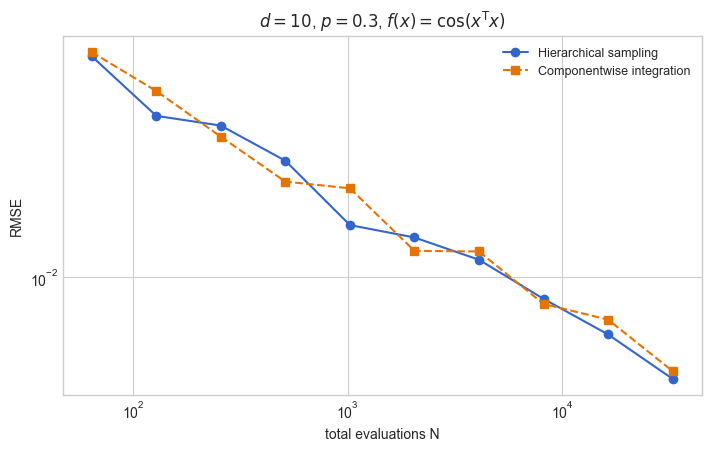

| Hierarchical sampling slope | Componentwise integration slope | Final Hierarchical sampling RMSE | Final Componentwise integration RMSE |
| --- | --- | --- | --- |
| -0.485 | -0.419 | 0.00383883802 | 0.00412968216 |

In [15]:
values_v_cos10 = np.cos(np.sum(x10**2, axis=-1))
values1_cos10 = np.cos(np.sum(x1_10**2, axis=-1))
values2_cos10 = np.cos(np.sum(x2_10**2, axis=-1))

rmse_v_cos10 = []
rmse_separate_cos10 = []
for n in sample_sizes:
    estimates_v_cos10 = values_v_cos10[:, :n].mean(axis=1)
    estimates_separate_cos10 = (
        p_cos10 * values1_cos10[:, : n // 2].mean(axis=1)
        + (1 - p_cos10) * values2_cos10[:, : n // 2].mean(axis=1)
    )
    rmse_v_cos10.append(
        np.sqrt(np.mean((estimates_v_cos10 - exact_cos_mixture) ** 2))
    )
    rmse_separate_cos10.append(
        np.sqrt(np.mean((estimates_separate_cos10 - exact_cos_mixture) ** 2))
    )

rmse_v_cos10 = np.asarray(rmse_v_cos10)
rmse_separate_cos10 = np.asarray(rmse_separate_cos10)
slope_v_cos10 = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_v_cos10[fit]), 1
)[0]
slope_separate_cos10 = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate_cos10[fit]), 1
)[0]

fig, ax = plt.subplots(figsize=(7.0, 4.4), layout="constrained")
ax.loglog(
    sample_sizes, rmse_v_cos10, "o-", color="#3366CC",
    label="Hierarchical sampling",
)
ax.loglog(
    sample_sizes, rmse_separate_cos10, "s--", color="#E67300",
    label="Componentwise integration",
)
ax.set(
    xlabel="total evaluations N", ylabel="RMSE",
    title=r"$d=10$, $p=0.3$, $f(x)=\cos(x^\mathsf{T}x)$",
)
ax.legend(frameon=False, fontsize=9)
plt.show()

show_table(
    ["Hierarchical sampling slope", "Componentwise integration slope", "Final Hierarchical sampling RMSE", "Final Componentwise integration RMSE"],
    [[f"{slope_v_cos10:.3f}", f"{slope_separate_cos10:.3f}",
      f"{rmse_v_cos10[-1]:.9g}", f"{rmse_separate_cos10[-1]:.9g}"]],
)


### What this tells us

The fitted slopes are now $-0.485$ for Hierarchical mixture sampling and $-0.419$ for Componentwise integration, much less negative than in the same mixture's quadratic test ($-0.813$ and $-1.099$). Hierarchical mixture sampling has slightly smaller final RMSE here. To see whether this reversal is typical, we return to the same 100 paired cases.


## 7. Same 100 mixtures with $\cos(x^\mathsf{T}x)$

We change only the integrand in the Section 5 study. The 100 component pairs, the QMC point sets, both probabilities, and the 32 randomizations are reused exactly. `gaussian_cos_squared_norm` supplies each component's reference; no additional Monte Carlo checks are needed.

The seed-replay helper preserves the original streams without advancing their counters. As before, the curves show median RMSE, and the bands are 25th–75th percentiles across mixtures, not confidence intervals.


In [16]:
def replay_case_seed(case_seed):
    """Replay a case from child zero without advancing the Section 5 seed."""
    return np.random.SeedSequence(
        case_seed.entropy,
        spawn_key=case_seed.spawn_key,
        pool_size=case_seed.pool_size,
    )


def random_cos_mixture_rmse(case_seed, budgets, n_rep, probabilities):
    """Return paired cosine RMSE curves: probability, method, budget."""
    d_case = 10
    parameter_seed, v_seed, c1_seed, c2_seed = replay_case_seed(case_seed).spawn(4)
    rng_case = np.random.default_rng(parameter_seed)
    mean1 = rng_case.standard_normal(d_case)
    mean2 = rng_case.standard_normal(d_case)
    factor1 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    factor2 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    covariance1 = factor1 @ factor1.T
    covariance2 = factor2 @ factor2.T
    exact1 = gaussian_cos_squared_norm(mean1, covariance1)
    exact2 = gaussian_cos_squared_norm(mean2, covariance2)
    max_budget = int(budgets[-1])

    # Same component points as Section 5, reused for both probabilities.
    component_estimates = []
    for mean, factor, seed in [
        (mean1, factor1, c1_seed), (mean2, factor2, c2_seed)
    ]:
        u_case = DigitalNetB2(
            d_case, seed=seed, replications=n_rep, randomize="LMS DS"
        )(max_budget // 2)
        x_case = to_normal(u_case) @ factor.T + mean
        values = np.cos(np.sum(x_case**2, axis=-1))
        component_estimates.append(
            np.stack([values[:, : n // 2].mean(axis=1) for n in budgets], axis=1)
        )
        del u_case, x_case, values

    # Same first ten U coordinates and final V coordinate as Section 5.
    points_case = DigitalNetB2(
        d_case + 1, seed=v_seed, replications=n_rep, randomize="LMS DS"
    )(max_budget)
    normals = to_normal(points_case[..., :d_case])
    selector = points_case[..., -1].copy()
    del points_case

    curves = np.empty((len(probabilities), 2, len(budgets)))
    for probability_index, probability in enumerate(probabilities):
        exact_mix = probability * exact1 + (1 - probability) * exact2
        choose1 = selector < probability
        values = np.empty(selector.shape)
        values[choose1] = np.cos(np.sum(
            (normals[choose1] @ factor1.T + mean1) ** 2, axis=-1
        ))
        values[~choose1] = np.cos(np.sum(
            (normals[~choose1] @ factor2.T + mean2) ** 2, axis=-1
        ))
        estimates_v = np.stack(
            [values[:, :n].mean(axis=1) for n in budgets], axis=1
        )
        estimates_separate = (
            probability * component_estimates[0]
            + (1 - probability) * component_estimates[1]
        )
        curves[probability_index, 0] = np.sqrt(
            np.mean((estimates_v - exact_mix) ** 2, axis=0)
        )
        curves[probability_index, 1] = np.sqrt(
            np.mean((estimates_separate - exact_mix) ** 2, axis=0)
        )
    return curves


In [17]:
# Same axes as Section 5: case, probability, method (Hierarchical sampling/Componentwise integration), budget.
rmse_cos_cases100 = np.empty_like(rmse_cases100)
slopes_cos_cases100 = np.empty_like(slopes_cases100)
started_cos100 = perf_counter()
for case_index_cos100, case_seed_cos100 in enumerate(case_seeds100):
    curves_cos100 = random_cos_mixture_rmse(
        case_seed_cos100, sample_sizes, replications, p_values100
    )
    rmse_cos_cases100[case_index_cos100] = curves_cos100
    for probability_index_cos100 in range(len(p_values100)):
        for method_index_cos100 in range(2):
            slopes_cos_cases100[
                case_index_cos100, probability_index_cos100, method_index_cos100
            ] = np.polyfit(
                np.log(sample_sizes[fit]),
                np.log(curves_cos100[
                    probability_index_cos100, method_index_cos100, fit
                ]),
                1,
            )[0]
elapsed_cos100 = perf_counter() - started_cos100
final_ratios_cos100 = rmse_cos_cases100[:, :, 0, -1] / rmse_cos_cases100[:, :, 1, -1]


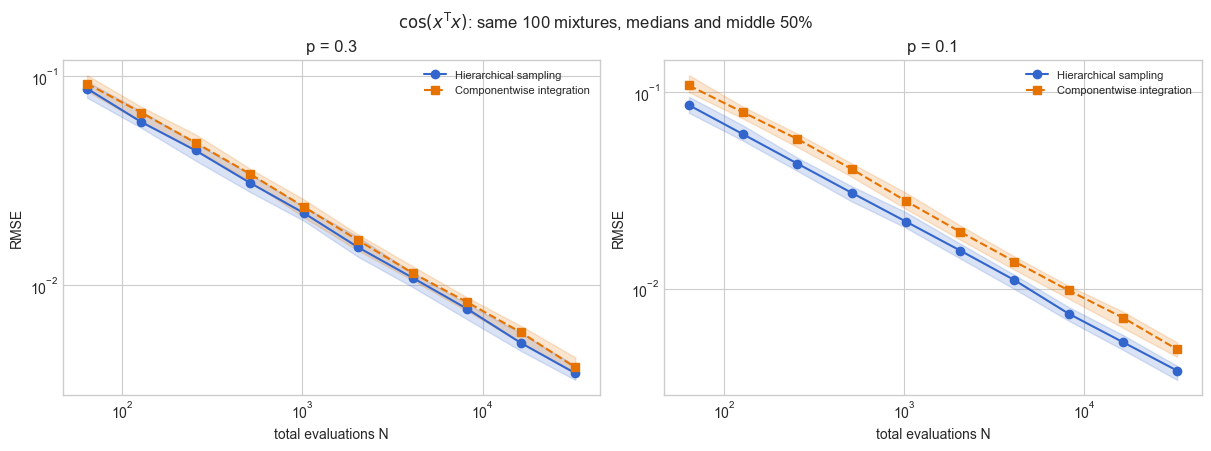

| p | Method | Median slope | 25%–75% slope | Median final RMSE |
| --- | --- | --- | --- | --- |
| 0.3 | Hierarchical sampling | -0.493 | [-0.543, -0.457] | 0.00380472 |
| 0.3 | Componentwise integration | -0.487 | [-0.531, -0.445] | 0.00405723 |
| 0.1 | Hierarchical sampling | -0.511 | [-0.552, -0.470] | 0.00381571 |
| 0.1 | Componentwise integration | -0.491 | [-0.525, -0.455] | 0.00489487 |

In [18]:
rmse_quantiles_cos100 = np.quantile(rmse_cos_cases100, [0.25, 0.5, 0.75], axis=0)
slope_quantiles_cos100 = np.quantile(slopes_cos_cases100, [0.25, 0.5, 0.75], axis=0)
ratio_medians_cos100 = np.median(final_ratios_cos100, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), layout="constrained")
for ip_cos100, (ax, p_cos100) in enumerate(zip(axes, p_values100)):
    for im_cos100, color_cos100, style_cos100, label_cos100 in [
        (0, "#3366CC", "o-", "Hierarchical sampling"),
        (1, "#E67300", "s--", "Componentwise integration"),
    ]:
        lower_cos100, median_cos100, upper_cos100 = rmse_quantiles_cos100[
            :, ip_cos100, im_cos100
        ]
        ax.loglog(
            sample_sizes, median_cos100, style_cos100,
            color=color_cos100, label=label_cos100,
        )
        ax.fill_between(
            sample_sizes, lower_cos100, upper_cos100, color=color_cos100, alpha=0.18
        )
    ax.set(xlabel="total evaluations N", ylabel="RMSE", title=f"p = {p_cos100}")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(r"$\cos(x^\mathsf{T}x)$: same 100 mixtures, medians and middle 50%")
plt.show()

nonlinear_rows = []
for ip_cos100, p_cos100 in enumerate(p_values100):
    for im_cos100, method_cos100 in enumerate(["Hierarchical sampling", "Componentwise integration"]):
        q25_cos, median_slope_cos, q75_cos = slope_quantiles_cos100[
            :, ip_cos100, im_cos100
        ]
        median_final_cos = rmse_quantiles_cos100[1, ip_cos100, im_cos100, -1]
        nonlinear_rows.append([
            p_cos100, method_cos100, f"{median_slope_cos:.3f}",
            f"[{q25_cos:.3f}, {q75_cos:.3f}]", f"{median_final_cos:.6g}",
        ])
show_table(
    ["p", "Method", "Median slope", "25%–75% slope", "Median final RMSE"],
    nonlinear_rows,
)


### What this tells us

Both methods now have fitted slopes near $-0.5$ over the tested budgets, and Componentwise integration no longer has an accuracy advantage. Median per-case final RMSE ratios Hierarchical mixture sampling / Componentwise integration are **0.902** at $p=0.3$ and **0.769** at $p=0.1$. Hierarchical mixture sampling has larger final RMSE in only **29/100** and **6/100** cases, respectively, so its disadvantage with $x^\mathsf{T}x$ is not universal.

## 8. Evidence side by side

These studies are paired by mixture and QMC points. The table compares empirical slopes and within-case error ratios at the final budget, $N=32768$; it does not compare the absolute error scales of different integrands.


In [19]:
paired_integrand_slope_change = np.median(
    slopes_cos_cases100 - slopes_cases100, axis=0
)
paired_probability_slope_change = np.median(
    slopes_cos_cases100[:, 1, :] - slopes_cos_cases100[:, 0, :], axis=0
)
paired_probability_final_ratio = np.median(
    rmse_cos_cases100[:, 1, :, -1] / rmse_cos_cases100[:, 0, :, -1], axis=0
)

comparison_rows = []
for integrand, slope_summary, ratio_summary in [
    (r"$x^\mathsf{T}x$", slope_quantiles100, ratio_medians100),
    (r"$\cos(x^\mathsf{T}x)$", slope_quantiles_cos100, ratio_medians_cos100),
]:
    for ip, probability in enumerate(p_values100):
        comparison_rows.append([
            integrand, probability, f"{slope_summary[1, ip, 0]:.3f}",
            f"{slope_summary[1, ip, 1]:.3f}", f"{ratio_summary[ip]:.3f}",
        ])
show_table(
    ["Integrand", "p", "Hierarchical sampling median slope", "Componentwise integration median slope",
     "Median final RMSE ratio Hierarchical sampling / Componentwise integration"],
    comparison_rows,
)


| Integrand | p | Hierarchical sampling median slope | Componentwise integration median slope | Median final RMSE ratio Hierarchical sampling / Componentwise integration |
| --- | --- | --- | --- | --- |
| $x^\mathsf{T}x$ | 0.3 | -0.875 | -1.018 | 3.779 |
| $x^\mathsf{T}x$ | 0.1 | -0.956 | -1.031 | 2.343 |
| $\cos(x^\mathsf{T}x)$ | 0.3 | -0.493 | -0.487 | 0.902 |
| $\cos(x^\mathsf{T}x)$ | 0.1 | -0.511 | -0.491 | 0.769 |

A ratio **above 1** means Componentwise integration has smaller final RMSE; **below 1** means Hierarchical mixture sampling has smaller final RMSE. The table reports the median of the per-case ratios, not the ratio of two medians.

The strongest change is associated with the integrand, not the change from $p=0.3$ to $p=0.1$. For the quadratic integrand, Componentwise integration has clearly lower final RMSE and more negative fitted slopes. For $\cos(x^\mathsf{T}x)$, the fitted slopes are nearly the same and the median final RMSE ratio reverses in favor of Hierarchical mixture sampling. Thus the selector discontinuity alone does not explain the observed performance.

This table interprets these experiments; it is not a universal method-selection rule.

| Question | Evidence from these experiments | Interpretation |
|---|---|---|
| Estimating $E[x^\mathsf{T}x]$ | Componentwise integration has lower median final RMSE across the 100 paired 10D cases. | Componentwise integration is advantageous for this integrand under the tested equal-work design. |
| Estimating $E[\cos(x^\mathsf{T}x)]$ | Similar fitted slopes; Hierarchical sampling has smaller median final RMSE. | No evidence here that Componentwise integration is preferable. |
| Need a direct mixture sample set | Hierarchical sampling produces samples from the mixture in one construction. | This is a practical reason to retain the hierarchical mixture sampling approach. |


## 9. What can we conclude?

Hierarchical mixture sampling introduces a discontinuity through the component-selection step at $V=p$, but the experiments show that the discontinuity by itself does not determine the observed convergence behavior.

For $x^\mathsf{T}x$ across 100 correlated 10D mixtures, Componentwise integration has substantially lower final RMSE and more negative median fitted slopes under equal work. For $\cos(x^\mathsf{T}x)$ on the same mixtures and QMC points, that advantage disappears: the fitted slopes are similar and Hierarchical mixture sampling has smaller median final RMSE.

The current evidence therefore does not justify universally preferring one construction. For expectation estimation, the better construction can depend strongly on the integrand. Hierarchical mixture sampling remains useful as a direct mixture-sampling construction.

These are finite-budget numerical observations, not theoretical convergence rates or a theorem.
